In [1]:
import os
os.chdir("../")

from dotenv import load_dotenv
load_dotenv()
os.environ["WANDB_API_KEY"] = os.getenv("WANDB_API_KEY")

In [2]:
from ppm.wandb_utils import load_multiple_experiments
from visualization import (
    plot_bar, plot_learning_curves, plot_grouped_bars,
    plot_correlation_bars, plot_3d_manifold, plot_split_curves,
    plot_combined_curves, save_figure, PlotConfig, alias
)
import pandas as pd
import numpy as np

In [3]:
import sys, os, importlib.util
print("exe:", sys.executable)
print("cwd:", os.getcwd())
print("ppm spec:", importlib.util.find_spec("ppm"))


exe: /bin/python
cwd: /app
ppm spec: ModuleSpec(name='ppm', loader=<_frozen_importlib_external.SourceFileLoader object at 0xf5069c1a5ac0>, origin='/app/ppm/__init__.py', submodule_search_locations=['/app/ppm'])


In [5]:
PROJECTS = ["BPI20_PTC_lrz_001", "BPI20_PTC_spark_001", "baseline-nep"]
runs3, history = load_multiple_experiments(PROJECTS, force_update=True)

Fetched 33 runs and 2940 history entries to /app/metrics/BPI20_PTC_lrz_001.db
Fetched 61 runs and 1963 history entries to /app/metrics/BPI20_PTC_spark_001.db
Fetched 15 runs and 45 history entries to /app/metrics/baseline-nep.db
Loaded 109 runs from 3 experiments
Datasets: ['BPI20PrepaidTravelCosts', 'BPI12', 'BPI15', 'BPI17', 'BPI19', 'BPI20TravelPermitData', 'BPI20RequestForPayment']


In [10]:
runs=runs3

In [8]:
runs3["backbone"].unique()

<ArrowStringArray>
[                    'gpt2-mini',                          'gpt2',
                   'gpt2-medium',                    'gpt2-large',
                       'gpt2-xl',                    'qwen3-0.6b',
                    'qwen3-1.7b',                      'qwen3-4b',
                      'qwen3-8b', 'baseline_transition_frequency']
Length: 10, dtype: str

## Accuracy: LLM

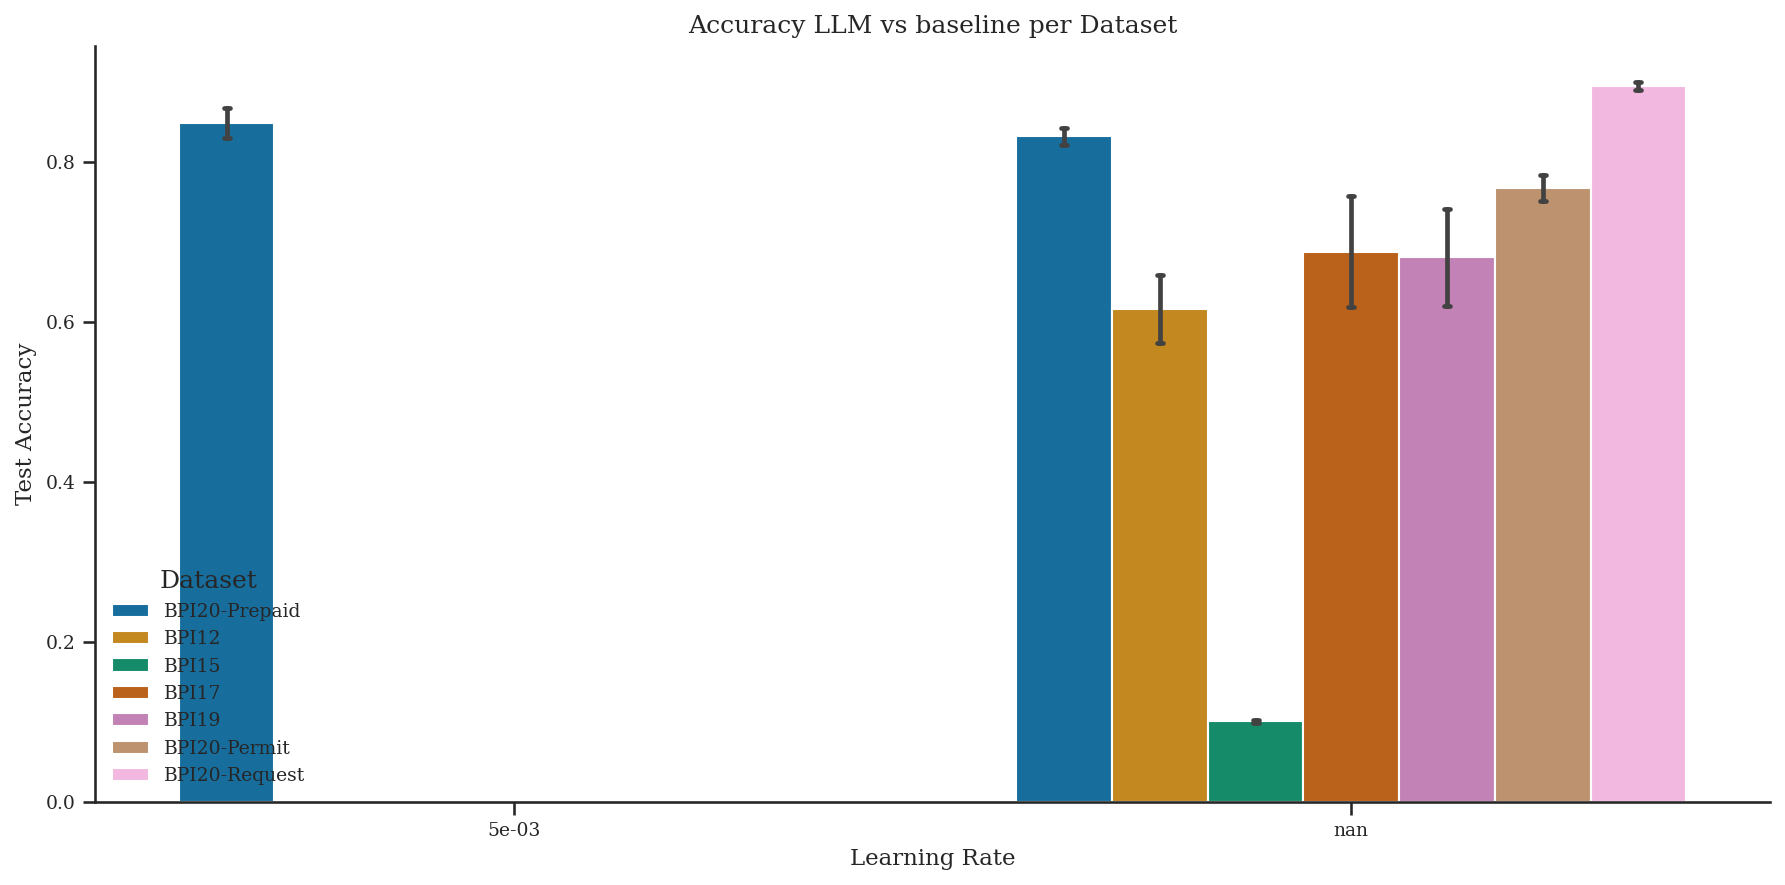

In [15]:
runs["lr_str"] = runs["lr"].apply(lambda x: f"{x:.0e}")
LR = .005
runs_filtered = runs[runs["lr"].isin([LR, np.nan])]

fig = plot_grouped_bars(
    runs_filtered,
    y="best_test_final_next_activity_acc",
    x="lr_str",
    hue="log",
    config=PlotConfig(
        figsize=(12, 6),
        title="Accuracy LLM vs baseline per Dataset",
        xlabel="Learning Rate",
        ylabel="Test Accuracy",
        legend_title="Dataset",
    )
)

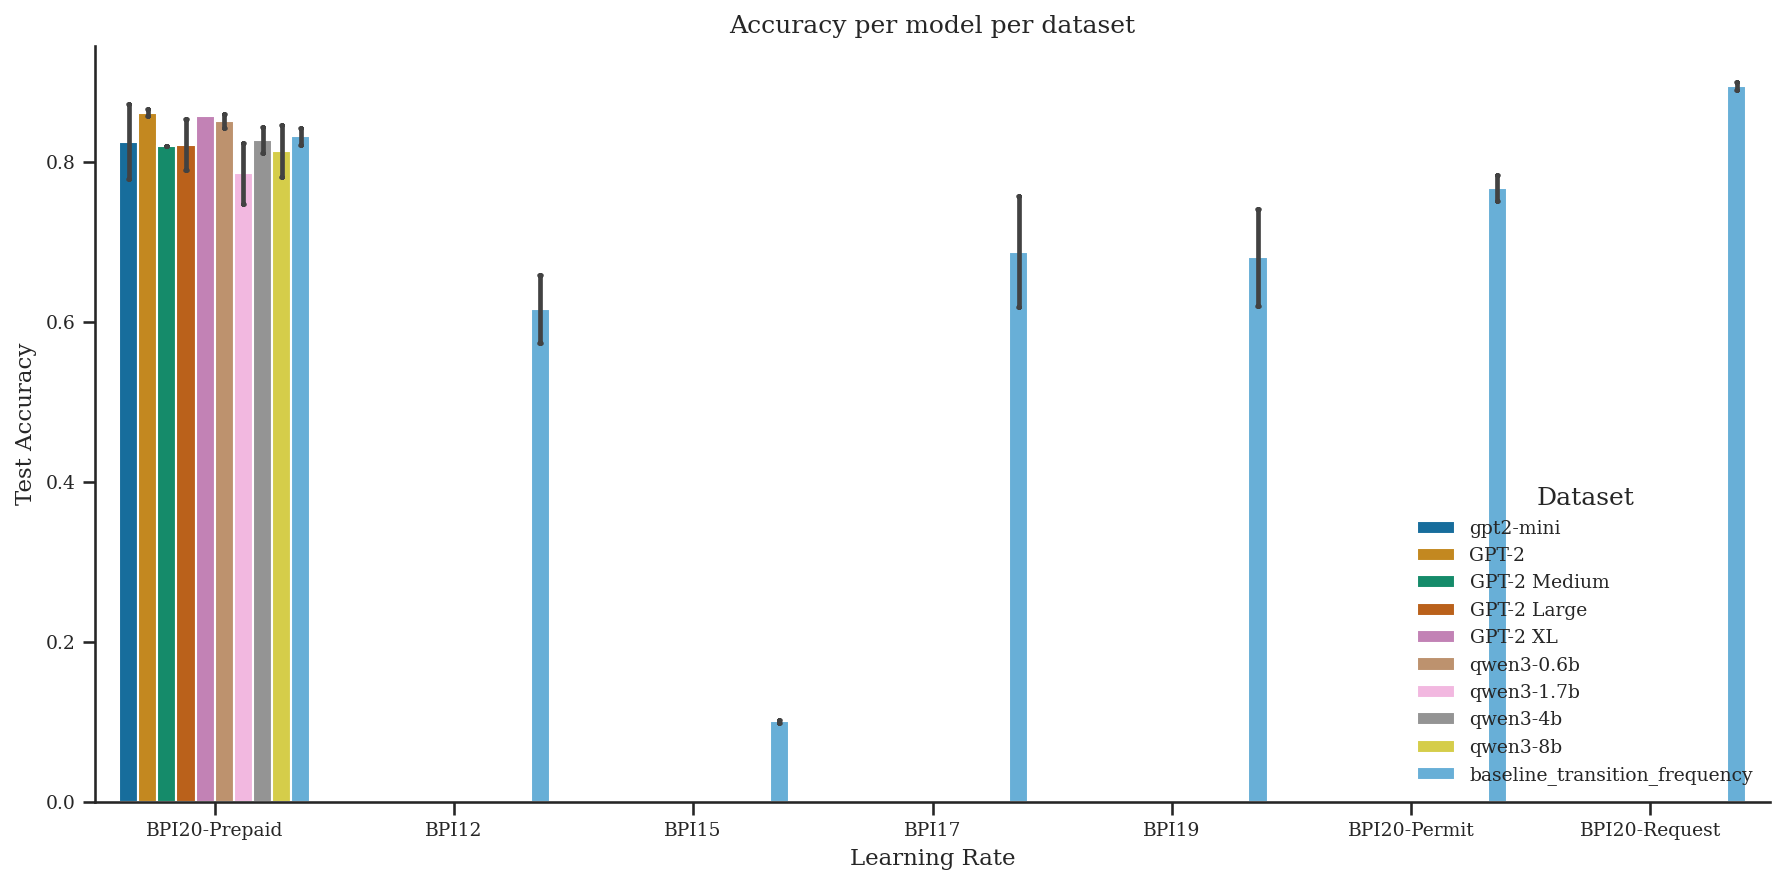

In [20]:
runs["lr_str"] = runs["lr"].apply(lambda x: f"{x:.0e}")
LR = .0005
runs_filtered = runs[runs["lr"].isin([LR, np.nan])]

fig = plot_grouped_bars(
    runs_filtered,
    y="best_test_final_next_activity_acc",
    x="log",
    hue="backbone",
    x_order = None,
    hue_order=['gpt2-mini', 'GPT-2', 'GPT-2 Medium',  'GPT-2 Large', 'baseline_transition_frequency'],
    config=PlotConfig(
        figsize=(12, 6),
        title="Accuracy per model per dataset",
        xlabel="Learning Rate",
        ylabel="Test Accuracy",
        legend_title="Dataset",
    )
)

In [13]:
print(runs["backbone"].unique())
runs[runs["backbone"]=="nan"]

<ArrowStringArray>
[                    'gpt2-mini',                          'gpt2',
                   'gpt2-medium',                    'gpt2-large',
                       'gpt2-xl',                    'qwen3-0.6b',
                    'qwen3-1.7b',                      'qwen3-4b',
                      'qwen3-8b', 'baseline_transition_frequency']
Length: 10, dtype: str


,id,name,r,lr,log,device,epochs,compile,backbone,n_layers,...,group,job_type,project,hidden_size,embedding_size,seed,prediction_table,transition_table,best_test_final_next_activity_f1_macro,lr_str


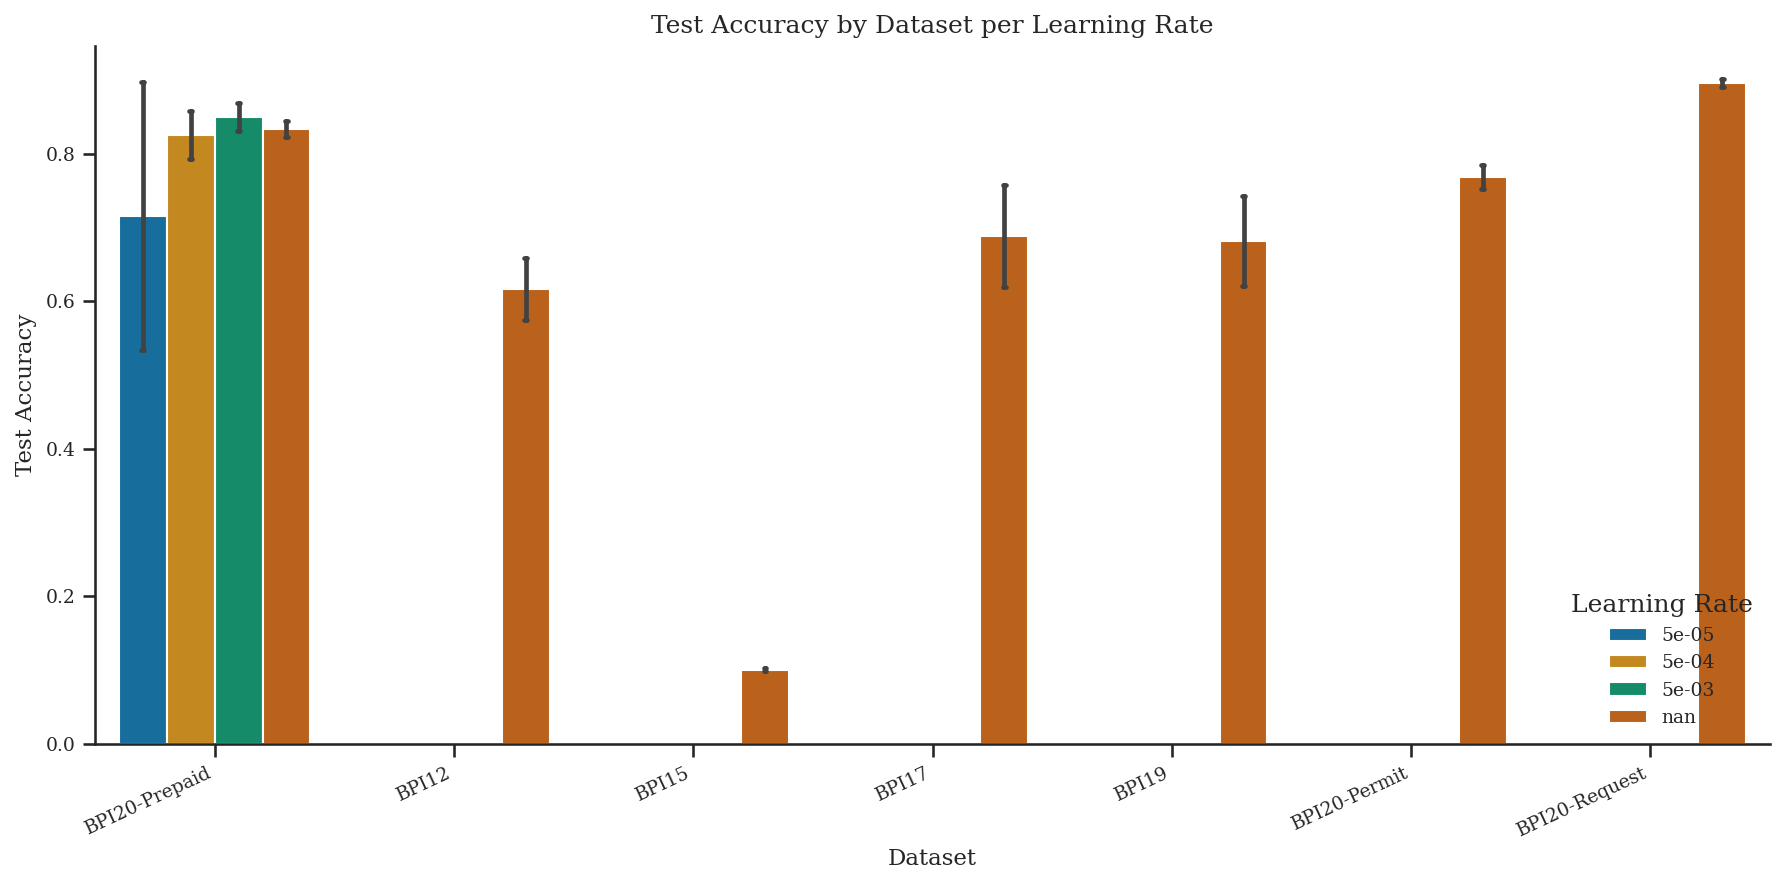

In [14]:
fig2 = plot_grouped_bars(
    runs,
    y="best_test_final_next_activity_acc",
    x="log",
    hue="lr_str",
    config=PlotConfig(
        figsize=(12, 6),
        title="Test Accuracy by Dataset per Learning Rate",
        xlabel="Dataset",
        ylabel="Test Accuracy",
        legend_title="Learning Rate",
        xtick_rotation=25,
    )
)

## Learning Curves: Accuracy & Loss over Epochs

In [7]:
max_step = history.groupby("run_id")["step"].max().min()
history_filtered = history[history["step"] <= max_step]

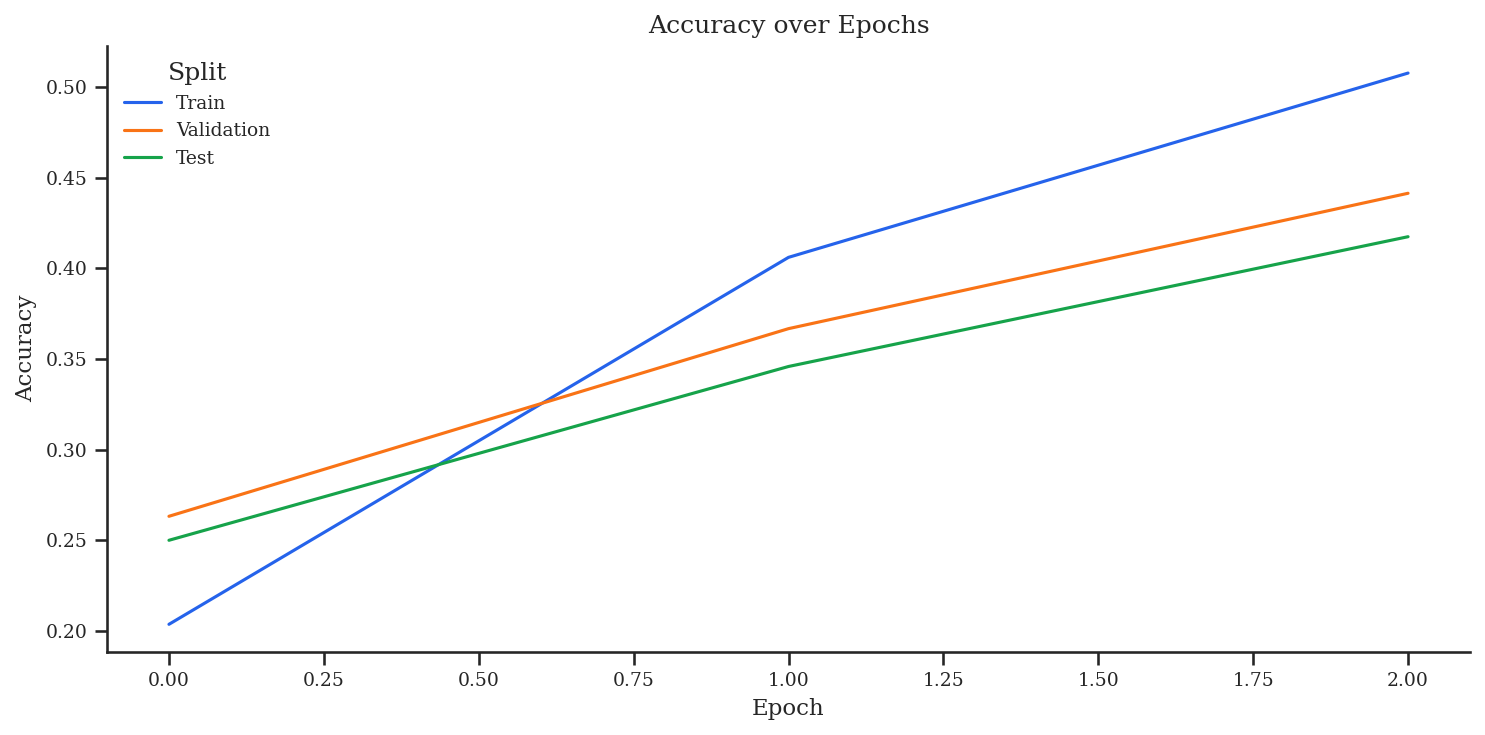

In [8]:
acc_metrics = {
    "train_next_activity_acc": "Train",
    "val_next_activity_acc": "Validation",
    "test_next_activity_acc": "Test",
}

fig_acc_curves = plot_split_curves(
    history_filtered,
    metrics=acc_metrics,
    config=PlotConfig(
        figsize=(10, 5),
        title="Accuracy over Epochs",
        xlabel="Epoch",
        ylabel="Accuracy",
        legend_title="Split",
    )
)

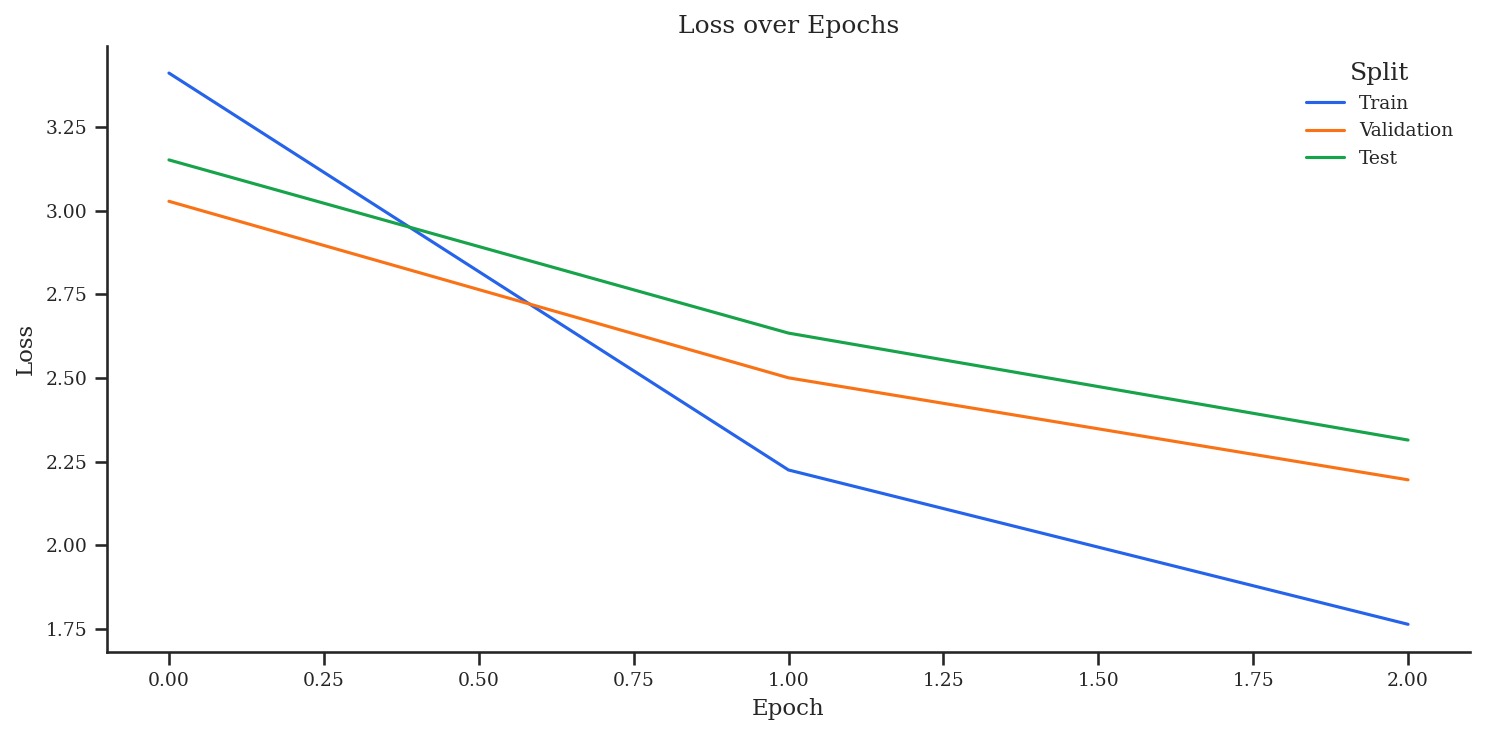

In [9]:
loss_metrics = {
    "train_next_activity_loss": "Train",
    "val_next_activity_loss": "Validation",
    "test_next_activity_loss": "Test",
}

fig_loss_curves = plot_split_curves(
    history_filtered,
    metrics=loss_metrics,
    config=PlotConfig(
        figsize=(10, 5),
        title="Loss over Epochs",
        xlabel="Epoch",
        ylabel="Loss",
        legend_title="Split",
    )
)

## Train/Val/Test Correlation

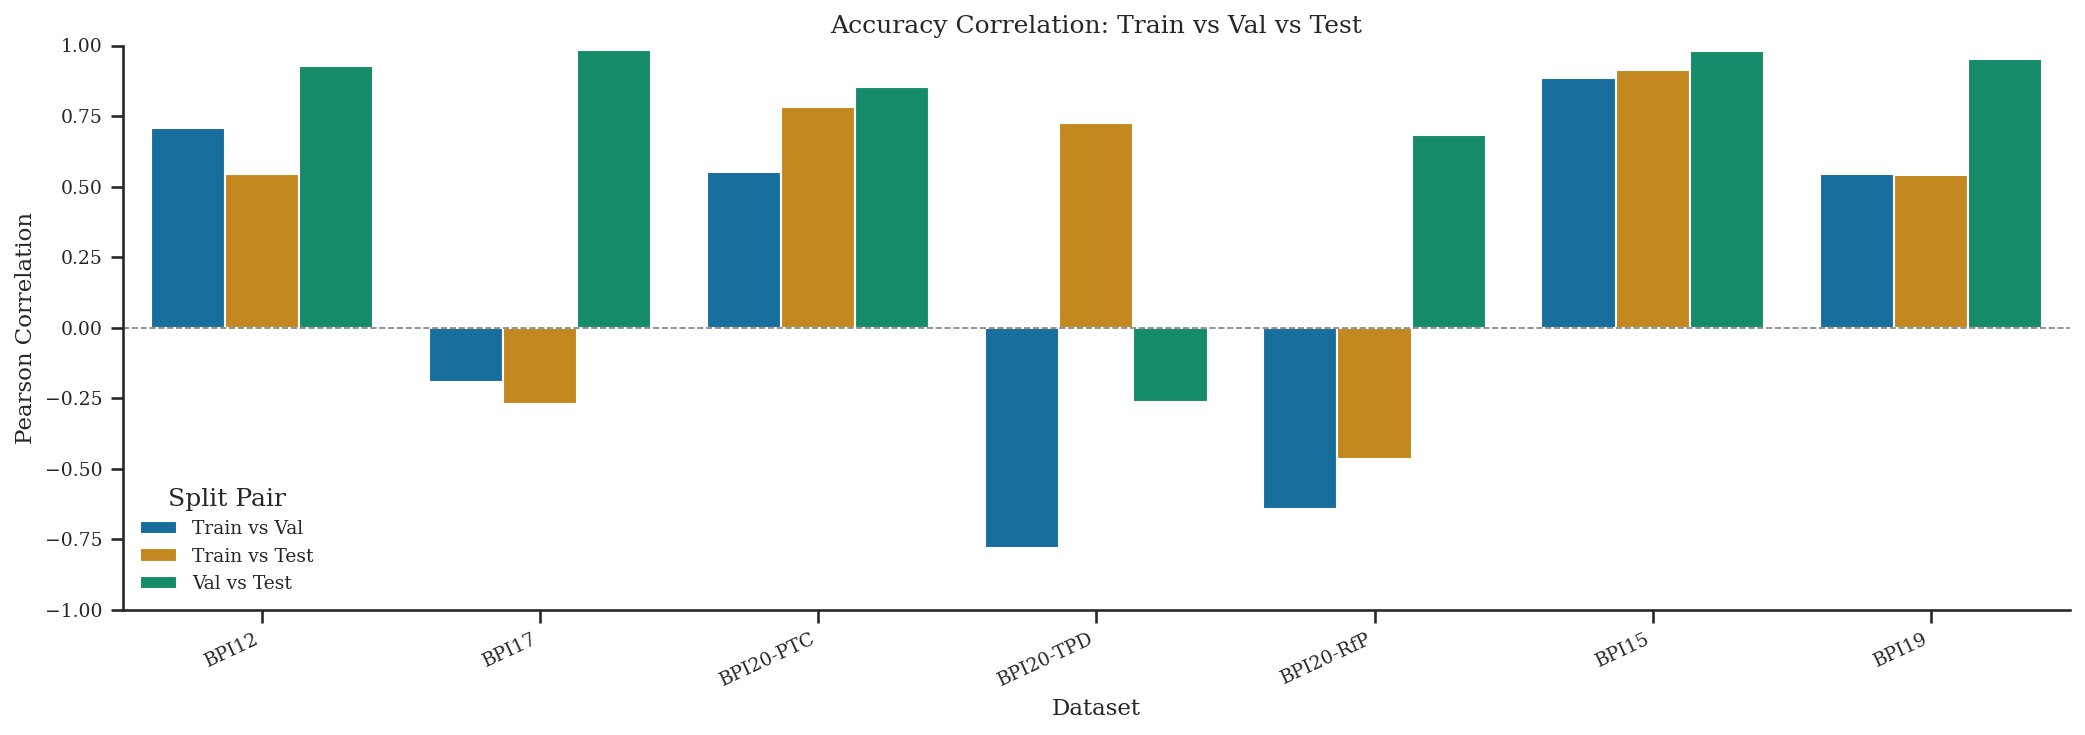

In [6]:
metric_pairs_acc = [
    ("train_next_activity_acc", "val_next_activity_acc"),
    ("train_next_activity_acc", "test_next_activity_acc"),
    ("val_next_activity_acc", "test_next_activity_acc"),
]

fig_acc = plot_correlation_bars(
    runs,
    group_col="log",
    metric_pairs=metric_pairs_acc,
    config=PlotConfig(
        figsize=(14, 5),
        title="Accuracy Correlation: Train vs Val vs Test",
        ylabel="Pearson Correlation",
        legend_title="Split Pair",
        xtick_rotation=25,
    )
)

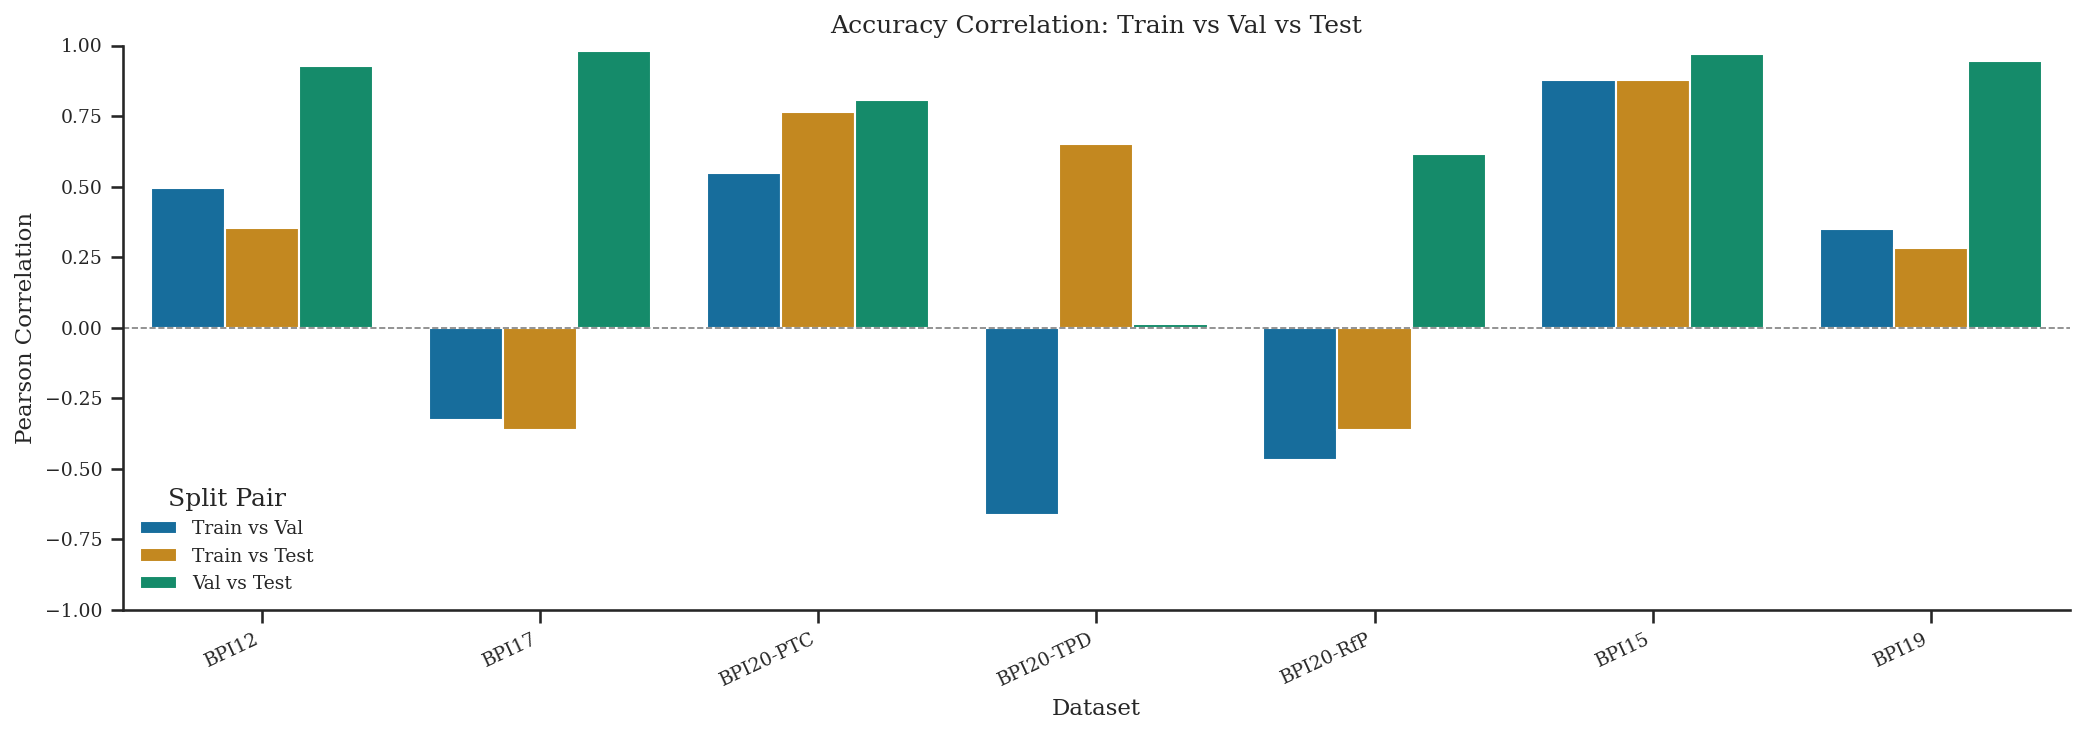

In [9]:
metric_pairs_loss = [
    ("train_next_activity_loss", "val_next_activity_loss"),
    ("train_next_activity_loss", "test_next_activity_loss"),
    ("val_next_activity_loss", "test_next_activity_loss"),
]

metric_pairs_acc = [
    ("train_next_activity_acc", "val_next_activity_acc"),
    ("train_next_activity_acc", "test_next_activity_acc"),
    ("val_next_activity_acc", "test_next_activity_acc"),
]

fig_loss = plot_correlation_bars(
    runs,
    group_col="log",
    metric_pairs=metric_pairs_acc,
    config=PlotConfig(
        figsize=(14, 5),
        title="Accuracy Correlation: Train vs Val vs Test",
        ylabel="Pearson Correlation",
        legend_title="Split Pair",
        xtick_rotation=25,
    )
)

## 3D Plot: Learning Rate x Dataset Size x Training Duration

In [11]:
runs["dataset_size"] = (
    runs["dataset/train_events"].fillna(0) + 
    runs["dataset/val_events"].fillna(0) + 
    runs["dataset/test_events"].fillna(0)
)

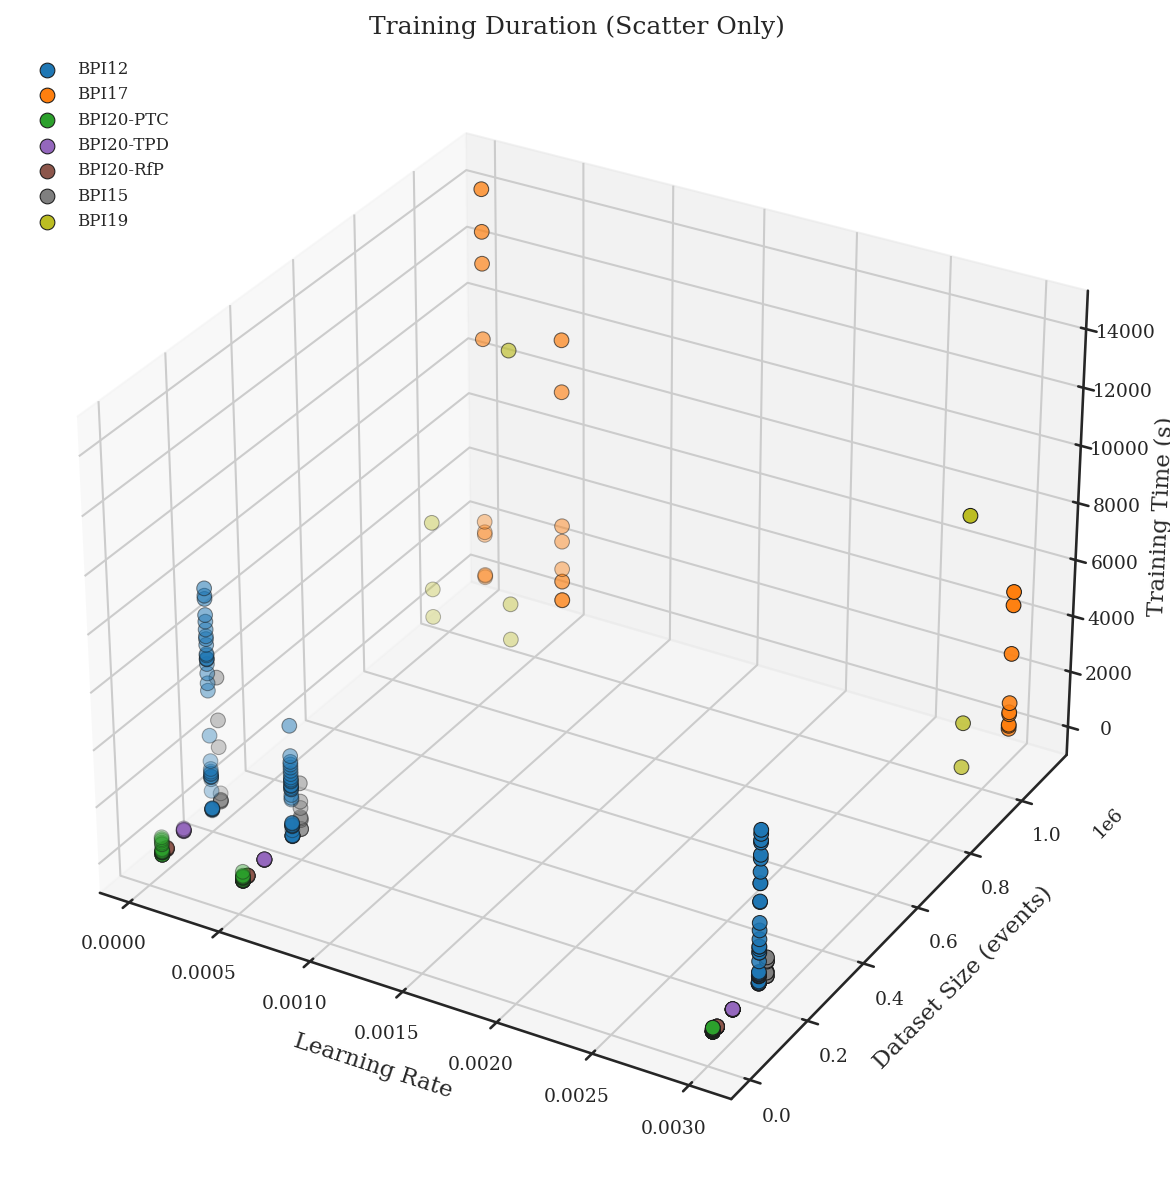

In [12]:
fig_3d = plot_3d_manifold(
    runs,
    x="lr",
    y="dataset_size",
    z="duration_sec",
    color="log",
    config=PlotConfig(
        figsize=(10, 8),
        title="Training Duration (Scatter Only)",
        xlabel="Learning Rate",
        ylabel="Dataset Size (events)",
    ),
    manifold=False,
    scatter=True,
)

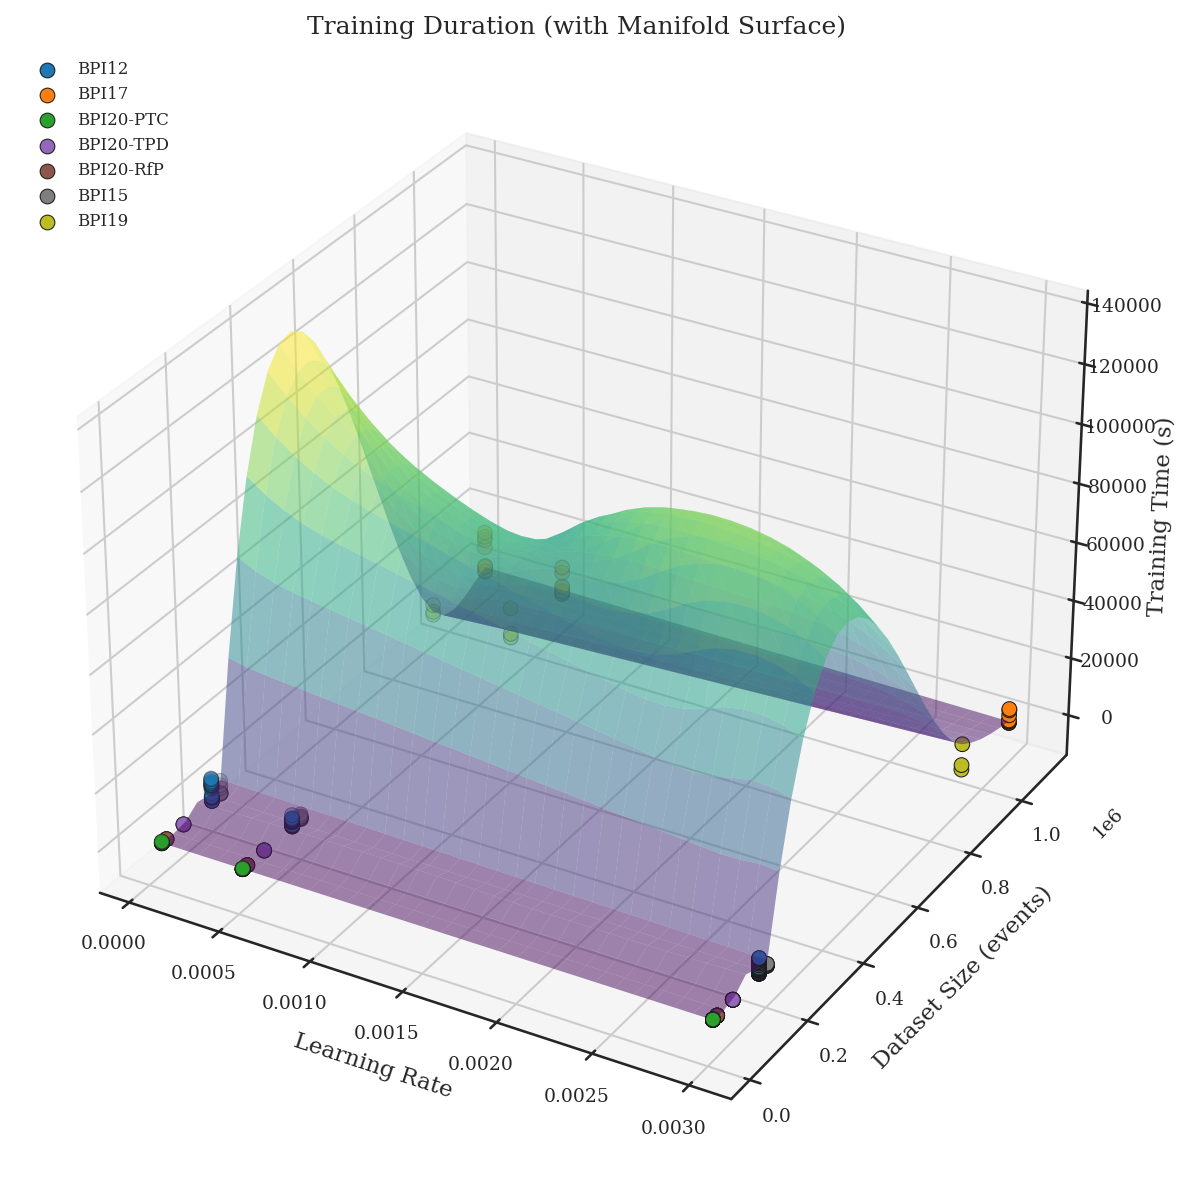

In [13]:
fig_3d_manifold = plot_3d_manifold(
    runs,
    x="lr",
    y="dataset_size",
    z="duration_sec",
    color="log",
    config=PlotConfig(
        figsize=(10, 8),
        title="Training Duration (with Manifold Surface)",
        xlabel="Learning Rate",
        ylabel="Dataset Size (events)",
    ),
    manifold=True,
    scatter=True,
)